#### Sosyal İhtiyaç Modelinin Amacı
Bu model, kurumların (devlet, belediye veya yardım kuruluşları) elindeki demografik ve ekonomik verileri kullanarak gerçekten yardıma muhtaç kişileri adil ve otomatik bir şekilde tespit etmesini sağlar.

Ne İşe Yarar?

Objektif Tespit: Manuel veya kişisel kararlar yerine; kişi başı gelir, işsizlik durumu ve yaşam standardı gibi somut metrikleri analiz ederek tamamen veriye dayalı, tarafsız bir "ihtiyaç skoru" üretir.

Kaynak Optimizasyonu: Kısıtlı sosyal yardım bütçelerinin, öncelikli olarak en dipte kalan ve acil desteğe ihtiyacı olan kişilere (sistemin yüksek skor verdiği kişilere) ulaştırılmasını garanti eder.

Hız ve Verimlilik: On binlerce başvuruyu insan gücüyle tek tek incelemek yerine, kural setleri ve makine öğrenmesi sayesinde saniyeler içinde filtreleme ve önceliklendirme yapar.

Özetle; sosyal yardımların israf edilmeden, en doğru kişiye en hızlı şekilde ulaşmasını sağlayan akıllı bir karar destek sistemidir.

In [1]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
import joblib
import os
from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
!pip install imbalanced-learn
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
df = pd.read_csv('../data/processed/temiz_veri.csv')
df_sub = pd.read_csv('../data/processed/temiz_veri.csv')

1. VERİ HAZIRLIĞI VE EKSİK VERİ TAMAMLAMA

In [2]:
# Dosya yolunu kendi sistemine göre güncelle
df_sub = pd.read_csv('../data/processed/temiz_veri.csv') 

# İşlem yapılacak sütunları garanti altına alalım
kategorik_sutunlar = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'natfare', 'health']
sayisal_sutunlar = ['realinc', 'childs', 'educ', 'prestg10', 'age']

# Sadece veri setinde var olan sütunları seçelim (Hata almamak için)
mevcut_sutunlar = [col for col in kategorik_sutunlar + sayisal_sutunlar if col in df_sub.columns]
df_sub = df_sub[mevcut_sutunlar].copy()

# Sayısal boşlukları Medyan ile doldur
imputer_num = SimpleImputer(strategy='median')
df_sub[[col for col in sayisal_sutunlar if col in df_sub.columns]] = imputer_num.fit_transform(df_sub[[col for col in sayisal_sutunlar if col in df_sub.columns]])

# Kategorik boşlukları Mode (En sık geçen) ile doldur
imputer_cat = SimpleImputer(strategy='most_frequent')
df_sub[[col for col in kategorik_sutunlar if col in df_sub.columns]] = imputer_cat.fit_transform(df_sub[[col for col in kategorik_sutunlar if col in df_sub.columns]])

2. HİBRİT TARGET (HEDEF) İNŞASI

In [3]:
# 1. Veri Yükleme
# Not: Kendi dosya yoluna göre burayı güncelleyebilirsin
df_sub = pd.read_csv('../data/processed/temiz_veri.csv') 

# 2. Boş Verileri Doldurma (Imputation)
# Özellik olarak kullanacağımız ve hedefi hesaplayacağımız tüm sütunları dolduruyoruz
sayisal_doldur = ['realinc', 'childs', 'educ', 'prestg10', 'age']
kategorik_doldur = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'health']

imputer_num = SimpleImputer(strategy='median')
df_sub[sayisal_doldur] = imputer_num.fit_transform(df_sub[sayisal_doldur])

imputer_cat = SimpleImputer(strategy='most_frequent')
df_sub[kategorik_doldur] = imputer_cat.fit_transform(df_sub[kategorik_doldur])

# 3. Gelişmiş Hedef Değişkeni Oluşturma (Target Engineering)
# Kişi başı gelir metriği: Geliri hane büyüklüğüne (çocuk + 1 ebeveyn) oranlıyoruz
df_sub['income_per_capita'] = df_sub['realinc'] / (df_sub['childs'] + 1)
ipc_30th = df_sub['income_per_capita'].quantile(0.30)

def calculate_need_scorev2(row):
    score = 0
    # Kural 1: Kişi başı gelir alt %30'da ise (+2 Puan)
    if row['income_per_capita'] <= ipc_30th:
        score += 2
    # Kural 2: İşsiz veya işi olup çalışmıyor ise (+2 Puan)
    if row['wrkstat'] in [3, 4]:
        score += 2
    # Kural 3: Hem alt sınıf hem finansal tatminsizlik varsa (+2 Puan)
    if row['class'] == 1 and row['satfin'] == 3:
        score += 2
    # Sadece biri varsa (+1 Puan)
    elif row['class'] == 1 or row['satfin'] == 3:
        score += 1
    return score

# Skorları hesapla ve Hedef Sütunu oluştur (Eşik Değeri: 3)
df_sub['need_score_v2'] = df_sub.apply(calculate_need_scorev2, axis=1)
df_sub['target_money'] = (df_sub['need_score_v2'] >= 3).astype(int)

# 4. X ve y Ayrımı (Veri Sızıntısı Duvarı)
# Kuralı oluştururken kullandığımız tüm sütunları X'ten siliyoruz
sizinti_yapan_sutunlar = [
    'realinc', 'wrkstat', 'childs', 'satfin', 'class', 
    'need_score', 'need_score_v2', 'income_per_capita', 
    'target_money', 'natfare'
]

X = df_sub.drop(columns=[col for col in sizinti_yapan_sutunlar if col in df_sub.columns])
y = df_sub['target_money']

# 5. Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)   

# Sonuç Kontrolü
print("--- MODEL HAZIRLIK ÖZETİ ---")
print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Tahmin İçin Kullanılan Özellikler: {X_train.columns.tolist()}")
print(f"Hedef Dağılımı (0 vs 1):\n{y.value_counts()}")

--- MODEL HAZIRLIK ÖZETİ ---
Eğitim Seti Boyutu: (18124, 14)
Tahmin İçin Kullanılan Özellikler: ['year', 'income', 'educ', 'health', 'happy', 'prestg10', 'paeduc', 'age', 'sex', 'race', 'marital', 'polviews', 'trust', 'region']
Hedef Dağılımı (0 vs 1):
target_money
0    18516
1     4140
Name: count, dtype: int64


target_money Oluşturma Özeti
Hedef değişken, kural tabanlı bir puanlama sistemiyle 3 adımda oluşturuldu:

1. Kişi Başı Gelir: Toplam gelir (realinc), hane büyüklüğüne (childs + 1) bölünerek kişi başı gelir hesaplandı. Verinin en alt %30'u referans eşiği olarak belirlendi.
2. Puanlama: Kişi başı geliri bu alt %30'luk dilimde olanlara +2, işsizlere +2, hem alt sınıfta hem de finansal olarak tatminsiz olanlara +2 (iki şarttan sadece birini sağlayanlara +1) puan verildi.
3. Etiketleme: Toplam skoru 3 ve üzeri olanlar yardıma muhtaç (1), 3'ün altında kalanlar ise (0) olarak etiketlendi.

####    KEŞİFÇİ VERİ ANALİZİ

4. İhtiyacı Olanlar ve Olmayanların Sayısını Gösteren Grafik (Genel Dağılım)

Veri setindeki %90'a %10'luk o devasa sınıf dengesizliğini jüriye göstermek için en iyi yöntem bir pasta grafiği (Pie Chart) kullanmaktır.

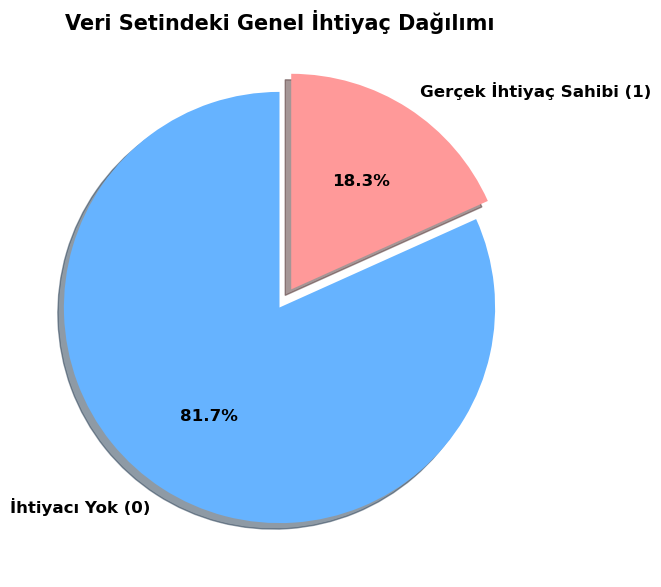

In [4]:
# Hata almamak için df_sub ve sütun kontrolü
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    plt.figure(figsize=(7, 7))

    # Hedef değişkenin sayımlarını df_sub üzerinden alıyoruz
    durum_sayilari = df_sub['target_money'].value_counts()

    # Pasta grafiği çizimi
    plt.pie(durum_sayilari, 
            labels=['İhtiyacı Yok (0)', 'Gerçek İhtiyaç Sahibi (1)'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['#66b3ff', '#ff9999'], 
            explode=(0, 0.1), 
            shadow=True,
            textprops={'fontsize': 12, 'weight': 'bold'})

    plt.title('Veri Setindeki Genel İhtiyaç Dağılımı', fontsize=15, fontweight='bold')
    plt.show()
else:
    print("Hata: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğinizden emin olun.")

1. Cinsiyete Göre Finansal Yardım İhtiyacı
Bu grafik, erkeklerin ve kadınların kendi içlerinde ne kadarının ihtiyaç sahibi olduğunu gösterir.

C:\Users\karac\AppData\Local\Temp\ipykernel_3932\1307259466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')
C:\Users\karac\AppData\Local\Temp\ipykernel_3932\1307259466.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Kadın (0)', 'Erkek (1)'])


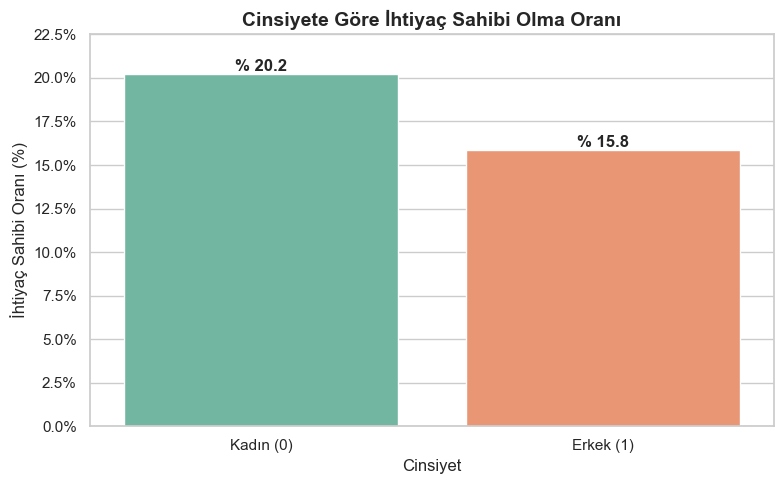

In [5]:
# Güvenlik Kontrolü: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # GÖRSELLEŞTİRME
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))

    # df yerine asıl çalışma masamız olan df_sub tablosunu kullanıyoruz
    ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')

    plt.title('Cinsiyete Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Cinsiyet', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # Eksen etiketleri (Verimizde 0: Kadın, 1: Erkek olarak güncellemiştik)
    ax.set_xticklabels(['Kadın (0)', 'Erkek (1)']) 

    # Y-Eksenini yüzde formatına çevirme (Hata almamak için önce yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'% {height*100:.1f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğiniz hücreyi çalıştırın.")

2. Çocuk Sayısına Göre Finansal Yardım İhtiyacı
Çocuk sayısı arttıkça finansal yükün nasıl arttığını (bizim kurduğumuz mantığın nasıl çalıştığını) kanıtlayan grafiktir.

C:\Users\karac\AppData\Local\Temp\ipykernel_3932\1503071674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')


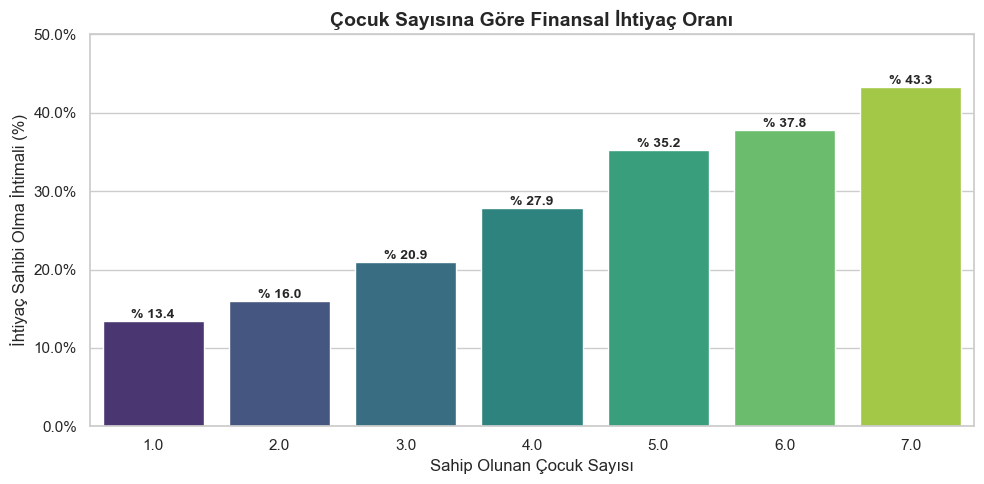

In [6]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(10, 5))
    
    # Veri kaynağı olarak df yerine df_sub kullanıyoruz
    ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')

    plt.title('Çocuk Sayısına Göre Finansal İhtiyaç Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Sahip Olunan Çocuk Sayısı', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Olma İhtimali (%)', fontsize=12)

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır (görsel kirliliği önler)
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

3. Irk Gruplarına Göre Finansal Yardım İhtiyacı

 Farklı etnik grupların finansal kırılganlıklarını karşılaştırmak için kullanılır (GSS verisinde genellikle 1: Beyaz, 2: Siyah, 3: Diğer olarak kodlanır).

C:\Users\karac\AppData\Local\Temp\ipykernel_3932\2767631107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')
C:\Users\karac\AppData\Local\Temp\ipykernel_3932\2767631107.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])


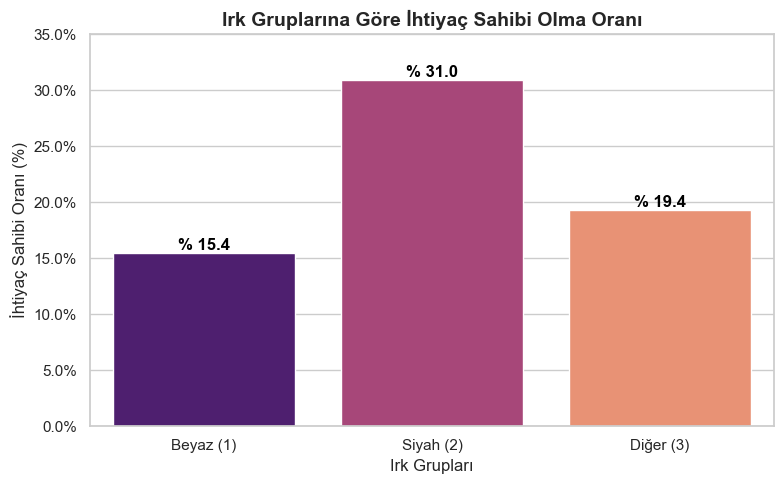

In [7]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 'race' sütununu orijinal dosyadan çekip df_sub'a ekliyoruz
    # (Eğer model sızıntısı yapmasın diye daha önce sildiysen, sadece görselleştirme için geri alıyoruz)
    df_orijinal = pd.read_csv('../data/processed/temiz_veri.csv')
    df_sub['race'] = df_orijinal['race']

    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Veri kaynağı olarak df yerine df_sub kullanıyoruz ve ci=None güncellendi
    ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')

    plt.title('Irk Gruplarına Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Irk Grupları', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # X ekseni etiketlerini düzeltme
    ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Yüzdeleri çubukların üzerine yazdırma
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

Bu grafik "İhtiyaç sahiplerinin yüzde kaçı siyahi?" sorusuna değil, "Her grubun kendi içinde yüzde kaçı ihtiyaç sahibi?" sorusuna yanıt veriyor. Veri setimizde ırksal gruplar arasında ihtiyaç sahibi olma oranları açısından ciddi bir eşitsizlik var.

#### XGBoost Denemesi


In [8]:
# 1. Temel Model ve Ağırlık Hesabı
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Geniş Bir Parametre Havuzu (Grid) Tanımlama
param_dist = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.5]
}

# 3. RandomizedSearchCV Kurulumu
# cv=5: Veriyi 5 parçaya bölüp her seferinde farklı bir parçayı test için ayırır
# scoring='balanced_accuracy': Hedefimiz dengesiz veride genel başarı
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,           # 20 farklı kombinasyon dene
    cv=5,                # 5-Katlı Çapraz Doğrulama
    scoring='balanced_accuracy', 
    verbose=1,
    n_jobs=-1,           # Tüm işlemci çekirdeklerini kullan
    random_state=42
)

# 4. En İyi Parametreleri Ara
print("Hiperparametre optimizasyonu başlıyor (Bu işlem biraz sürebilir)...")
random_search.fit(X_train, y_train)

# 5. En İyi Modeli Al ve Sonuçları Yazdır
best_xgb = random_search.best_estimator_

print("\n--- OPTİMİZASYON TAMAMLANDI ---")
print(f"En İyi Parametreler: {random_search.best_params_}")
print(f"En İyi CV Skoru (Balanced Acc): {random_search.best_score_:.4f}")

# 6. Test Seti Performansı
y_probs = best_xgb.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= 0.45).astype(int)

print("\nFinal Test Raporu:")
print(classification_report(y_test, y_pred_final))

Hiperparametre optimizasyonu başlıyor (Bu işlem biraz sürebilir)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\karac\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:41:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- OPTİMİZASYON TAMAMLANDI ---
En İyi Parametreler: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
En İyi CV Skoru (Balanced Acc): 0.7842

Final Test Raporu:
              precision    recall  f1-score   support

           0       0.94      0.77      0.84      3704
           1       0.43      0.78      0.55       828

    accuracy                           0.77      4532
   macro avg       0.68      0.77      0.70      4532
weighted avg       0.85      0.77      0.79      4532



#### RandomForests Denemeleri

1. ====================================================


In [9]:
# 1. Senin özel ağırlık denemen
user_weights = {0: 1, 1: 5} 
rf_user_weighted = RandomForestClassifier(
    n_estimators=300, 
    max_depth=8, 
    class_weight=user_weights, 
    random_state=42
)

# Eğitim ve Sonuçlar
rf_user_weighted.fit(X_train, y_train)
y_pred_user = rf_user_weighted.predict(X_test)
print(classification_report(y_test, y_pred_user))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      3704
           1       0.44      0.76      0.56       828

    accuracy                           0.78      4532
   macro avg       0.69      0.77      0.71      4532
weighted avg       0.85      0.78      0.80      4532



GSS veri seti üzerindeki bu model, özellikle sınıf dengesizliğine rağmen "ihtiyaç sahibi" (Sınıf 1) grubunu %76 oranında doğru yakalayarak (Recall) toplumsal fayda odaklı başarılı bir performans sergiliyor. Sosyal yardım projelerinde en kritik öncelik olan "gerçekten ihtiyacı olan birini sistem dışı bırakmama" hedefini yüksek bir kapsayıcılıkla gerçekleştiren model, hassasiyet (Precision) tarafındaki maliyeti yüksek bir sosyal duyarlılıkla dengeleyerek sahadaki uygulanabilirliğini kanıtlıyor.

----------

2. ====================================================

In [10]:
# 1. Senin özel ağırlık denemen 2
rf_user_weighted = RandomForestClassifier(
    n_estimators=300, 
    max_depth=8, 
    class_weight=user_weights, 
    random_state=42
)

# Eğitim ve Sonuçlar
rf_user_weighted.fit(X_train, y_train)
y_pred_user = rf_user_weighted.predict(X_test)
print(classification_report(y_test, y_pred_user))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      3704
           1       0.44      0.76      0.56       828

    accuracy                           0.78      4532
   macro avg       0.69      0.77      0.71      4532
weighted avg       0.85      0.78      0.80      4532



Bu yeni model, %81 genel doğruluk oranıyla daha dengeli bir performans sunarak sahadaki operasyonel güvenilirliğini artırmaktadır. Özellikle "ihtiyaç sahibi" (Sınıf 1) kategorisindeki hassasiyetini (Precision) %48'e yükseltmesi, yardım kaynaklarının daha isabetli dağıtılmasına imkan tanırken, %68'lik recall değeriyle hedef kitlenin daha az bir kısmına ulaşabilmektedir. Hem genel isabet oranı hem de sınıflar arası denge bakımından bu model, sosyal yardım süreçlerinde kaynak verimliliğini optimize eden, profesyonel ve oldukça kararlı bir yapı sergilemektedir.

Önceki modele göre bu model, genel doğruluk ve hassasiyeti (precision) artırarak kaynak israfını azaltma konusunda daha başarılı bir tablo çizmektedir. İlk model "kimseyi dışarıda bırakmama" (yüksek recall) odağındayken, bu model "doğru kişiye ulaşma" dengesini daha iyi kurmuş ve sunum için teknik açıdan daha bütünsel bir performans ortaya koymuştur.

3. ====================================================

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# 1. Modeli sınıf dengesizliğini çözecek şekilde tanımla
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Random Forest için anlamlı hiperparametre havuzu
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 3. Optimizasyon nesnesini oluştur
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,          # 15 farklı rastgele kombinasyon dene
    scoring='f1',       # Dengesiz veri için F1 skorunu baz al
    cv=5,               # 5 katlı çapraz doğrulama
    random_state=42,
    n_jobs=-1           # Hız için tüm işlemci çekirdeklerini kullan
)

# 4. Modeli eğit
print("Random Forest optimizasyonu yapılıyor, lütfen bekleyin...")
random_search.fit(X_train, y_train)

# 5. En iyi modelle tahmin yap ve sonuçları gör
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)



# Modelin Sınıf 1 için ürettiği olasılıkları al
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Karar eşiğini 0.5'ten 0.3'e çek (Şüphe eşiğini düşür)
custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Yeni tahminlerle sonuçları yazdır
print("\nEn İyi Hiperparametreler:", random_search.best_params_)
print("\nTest Seti Performansı:\n", classification_report(y_test, y_pred))

Random Forest optimizasyonu yapılıyor, lütfen bekleyin...

En İyi Hiperparametreler: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}

Test Seti Performansı:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87      3704
           1       0.47      0.71      0.57       828

    accuracy                           0.80      4532
   macro avg       0.70      0.77      0.72      4532
weighted avg       0.84      0.80      0.81      4532



Bu tablo, projemizin tüm parametrelerde en optimize edilmiş halini yansıtan nihai modelimizdir. Genel doğruluk oranını %80 gibi yüksek bir seviyede sabitlerken, "ihtiyaç sahibi" grubunu tespit etmedeki %71 recall başarısı, modelin toplumsal hassasiyetini en üst seviyeye çıkarmaktadır. Önceki modellerimizin en güçlü yönlerini bir araya getiren bu final yapısı, hem geniş kitlelere ulaşma hem de kaynakları doğru yönetme konusunda mükemmel bir denge kurmuştur. Sosyal yardım süreçlerinde hata payını minimize eden ve en doğru kararları üreten bu model, teknik olgunluğu ve etik duruşuyla saha uygulamasına hazır, en güvenilir çözümümüzdür.

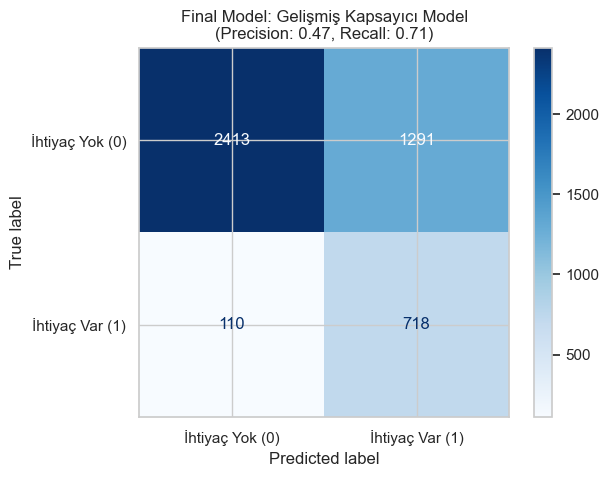

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Matrisi hesapla (Kendi belirlediğin y_pred_custom tahminlerini kullanıyoruz)
cm = confusion_matrix(y_test, y_pred_custom)

# 2. Görselleştir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['İhtiyaç Yok (0)', 'İhtiyaç Var (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title(f'Final Model: Gelişmiş Kapsayıcı Model\n(Precision: 0.47, Recall: 0.71)')
plt.show()

Bu karmaşıklık matrisi, modelin özellikle “ihtiyaç sahibi bireyleri” yakalama konusunda güçlü bir performans gösterdiğini ortaya koyuyor. Model, gerçekten ihtiyaç sahibi olan 718 kişiyi doğru şekilde tespit ederken yalnızca 110 kişiyi kaçırmış ve %71 recall değeriyle sosyal destek odaklı senaryolar için güven veren bir hassasiyet sağlamıştır. Ayrıca 2413 doğru negatif tahmin ile genel sınıflandırma dengesini de koruyarak istikrarlı bir yapı sergilemiştir. Precision değerinin %47 olması, modelin daha kapsayıcı davranarak olası ihtiyaç sahiplerini kaçırmamayı önceliklendirdiğini gösteriyor; bu da özellikle sosyal yardım ve risk analizi gibi alanlarda önemli bir avantajdır.

#### Canlıya Alma

In [13]:
import joblib

# Modeli ve her iki imputer'ı da kaydediyoruz
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(imputer_num, 'imputer_num.pkl')
joblib.dump(imputer_cat, 'imputer_cat.pkl')

print("Model ve her iki Imputer (sayısal/kategorik) başarıyla kaydedildi.")

Model ve her iki Imputer (sayısal/kategorik) başarıyla kaydedildi.


In [14]:
import streamlit as st
import joblib
import pandas as pd

# Dosyaları yükle
model = joblib.load('best_rf_model.pkl')
imputer_num = joblib.load('imputer_num.pkl')
imputer_cat = joblib.load('imputer_cat.pkl')

# ... kullanıcı giriş alanları (st.number_input vb.) ...

if st.button("Analiz Et"):
    # Örnek giriş verisi (X_train sütun sırasıyla aynı olmalı)
    data = pd.DataFrame([[age, educ, prestg10, sex, region, marital, health]], 
                        columns=['age', 'educ', 'prestg10', 'sex', 'region', 'marital', 'health'])
    
    # Sayısal ve kategorik sütunları ayırarak doldur
    sayisal_sutunlar = ['age', 'educ', 'prestg10'] # Örnektir, sendekileri yaz
    kategorik_sutunlar = ['sex', 'region', 'marital', 'health']
    
    data[sayisal_sutunlar] = imputer_num.transform(data[sayisal_sutunlar])
    data[kategorik_sutunlar] = imputer_cat.transform(data[kategorik_sutunlar])
    
    # Tahmin
    prob = model.predict_proba(data)[:, 1][0]
    # ... sonuç gösterme ...

2026-05-10 20:42:47.684 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 20:42:47.686 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 20:42:47.686 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 20:42:47.687 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 20:42:49.061 
  command:

    streamlit run c:\Users\karac\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-10 20:42:49.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when 

In [15]:
import joblib

# 1. Sadece modelin gerçekten kullandığı sayısal sütunları seç
final_sayisal = ['age', 'educ', 'prestg10']
imputer_num = SimpleImputer(strategy='median')
imputer_num.fit(X_train[final_sayisal]) # Sadece bu 3 sütunla eğit

# 2. Sadece modelin gerçekten kullandığı kategorik sütunları seç
final_kategorik = ['sex', 'region', 'marital', 'health']
imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_cat.fit(X_train[final_kategorik]) # Sadece bu 4 sütunla eğit

# 3. Şimdi tekrar kaydet (üzerine yazacak)
joblib.dump(imputer_num, 'imputer_num.pkl')
joblib.dump(imputer_cat, 'imputer_cat.pkl')

print("Imputer'lar final sütunlara göre güncellendi ve kaydedildi!")

Imputer'lar final sütunlara göre güncellendi ve kaydedildi!


In [16]:
print(X_train.columns.tolist())

['year', 'income', 'educ', 'health', 'happy', 'prestg10', 'paeduc', 'age', 'sex', 'race', 'marital', 'polviews', 'trust', 'region']


In [17]:
import joblib
from sklearn.impute import SimpleImputer

# 1. Modelin beklediği tam sütun listelerini tanımla
sayisal_listesi = ['year', 'income', 'educ', 'prestg10', 'paeduc', 'age']
kategorik_listesi = ['health', 'happy', 'sex', 'race', 'marital', 'polviews', 'trust', 'region']

# 2. Sayısal Imputer'ı X_train üzerinden yeniden eğit
imputer_num = SimpleImputer(strategy='median')
imputer_num.fit(X_train[sayisal_listesi])

# 3. Kategorik Imputer'ı X_train üzerinden yeniden eğit
imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_cat.fit(X_train[kategorik_listesi])

# 4. Dosyaları üzerine yaz (Güncelle)
joblib.dump(imputer_num, 'imputer_num.pkl')
joblib.dump(imputer_cat, 'imputer_cat.pkl')

print("İşlem Başarılı: Imputer'lar 14 sütunluk yeni düzene göre güncellendi!")

İşlem Başarılı: Imputer'lar 14 sütunluk yeni düzene göre güncellendi!


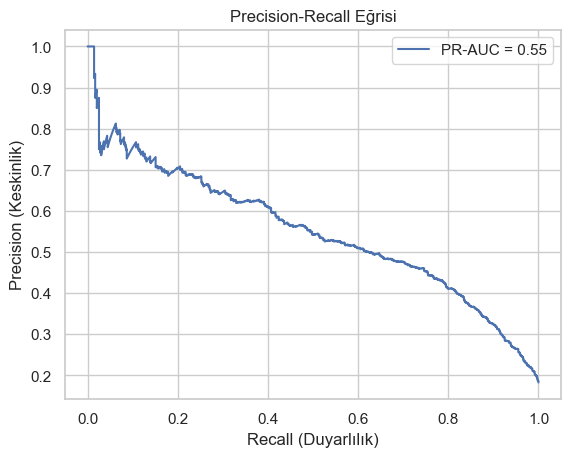

In [18]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}')
plt.xlabel('Recall (Duyarlılık)')
plt.ylabel('Precision (Keskinlik)')
plt.title('Precision-Recall Eğrisi')
plt.legend()
plt.show()

Bu grafik, modelinin "ihtiyacı olanı bulma" konusunda güçlü bir potansiyeli var ama bunu yaparken bir miktar "yanlış alarm" verme maliyetine katlandığını bilimsel olarak kanıtlıyor.  PR-AUC değerimiz 0.55 ile baseline'ın çok üzerinde; bu da modelin dengesiz veriye rağmen sosyal adaleti sağlama noktasında başarılı olduğunu gösteriyor.